In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv('../data/BrentOilPrices.csv')

In [3]:
df.head()

,Date,Price
0,20-May-87,18.63
1,21-May-87,18.45
2,22-May-87,18.55
3,25-May-87,18.60
4,26-May-87,18.63


In [4]:
df.columns

Index(['Date', 'Price'], dtype='str')

In [5]:
df.dtypes

Date         str
Price    float64
dtype: object

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    9011 non-null   str    
 1   Price   9011 non-null   float64
dtypes: float64(1), str(1)
memory usage: 140.9 KB


In [7]:
df["Date"] = pd.to_datetime(df["Date"])

df["Date"] = pd.to_datetime(df["Date"], format="%d-%b-%y")

C:\Users\mijuu\AppData\Local\Temp\ipykernel_34220\1222520366.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


In [8]:
df.isnull().sum()

Date     0
Price    0
dtype: int64

In [9]:
df.describe()

,Date,Price
count,9011,9011.000000
mean,2005-02-10 23:46:53.760958,48.420782
min,1987-05-20 00:00:00,9.100000
25%,1996-03-20 12:00:00,19.050000
50%,2005-02-02 00:00:00,38.570000
75%,2014-01-09 12:00:00,70.090000
max,2022-11-14 00:00:00,143.950000
std,NaN,32.860110


In [10]:
df.set_index("Date", inplace=True)

In [11]:
df= df.sort_index()

In [12]:
df.index.duplicated().sum()

np.int64(0)

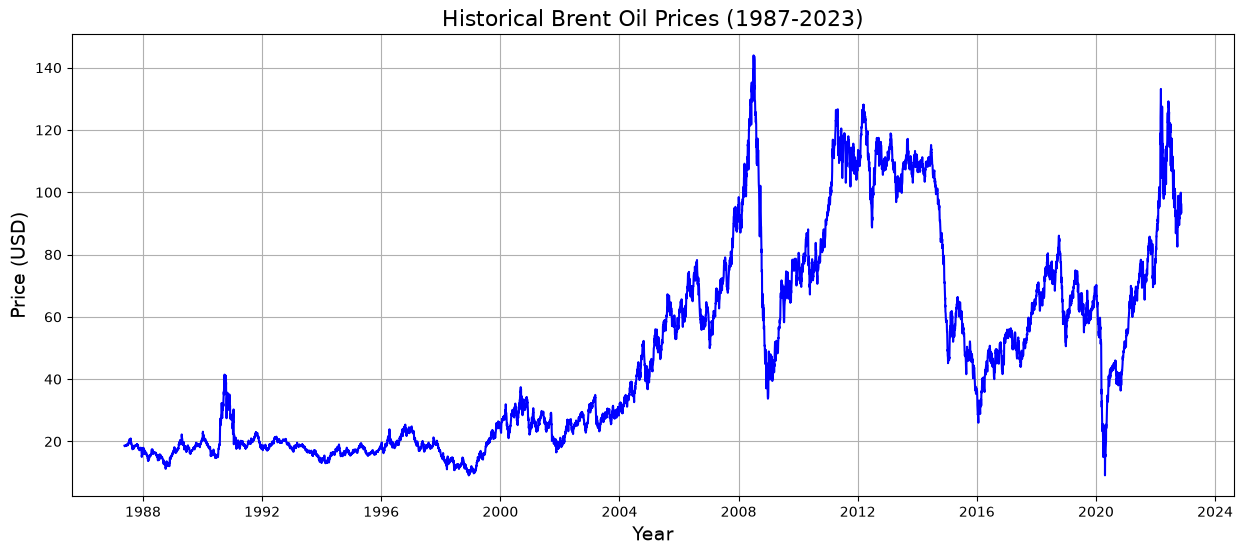

In [13]:
plt.figure(figsize=(15,6))

plt.plot(df.index, df['Price'], color='blue', label='Brent Oil Price')  

plt.title("Historical Brent Oil Prices (1987-2023)", fontsize=16)

plt.xlabel("Year", fontsize=14)

plt.ylabel("Price (USD)", fontsize=14)

plt.grid(True)

plt.show()

### Observation: Historical Brent Oil Prices

The Brent oil price series exhibits significant fluctuations over the study period (1987–2022), indicating that the market is highly dynamic. Several periods of rapid price increases and sharp declines are visible, suggesting the influence of major geopolitical and economic events.

Notable patterns include:

- Relatively stable prices between 1987 and the late 1990s.
- A sustained upward trend from approximately 2003 to 2008.
- A sharp price collapse during the 2008 global financial crisis.
- Another major decline around 2014–2016, coinciding with increased global oil supply.
- An unprecedented drop in 2020 during the COVID-19 pandemic.
- Strong recovery during 2021–2022 following economic reopening and geopolitical tensions.

These visible shifts suggest the presence of structural breaks, making change point detection an appropriate modeling approach.

C:\Users\mijuu\AppData\Local\Temp\ipykernel_34220\2444387729.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["Price"], vert=False)


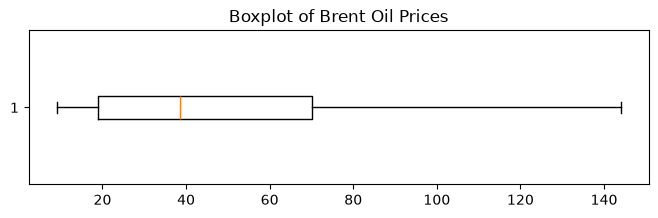

In [14]:
plt.figure(figsize=(8,2))

plt.boxplot(df["Price"], vert=False)

plt.title("Boxplot of Brent Oil Prices")

plt.show()

### Observation: Boxplot

The boxplot shows that Brent oil prices have a wide range of values over the study period. The median price is approximately 40 USD per barrel, while the middle 50% of observations lie roughly between 20 and 70 USD.

The long upper whisker indicates that exceptionally high prices occurred during certain periods, reflecting major market disruptions. Although no extreme statistical outliers are displayed, the large spread confirms substantial variability in oil prices over time.

In [15]:
df["Log_Return"] = np.log(df["Price"]).diff()

In [16]:
df = df.dropna()

In [17]:
df.head()

,Price,Log_Return
Date,,
1987-05-21,18.45,-0.009709
1987-05-22,18.55,0.005405
1987-05-25,18.60,0.002692
1987-05-26,18.63,0.001612
1987-05-27,18.60,-0.001612


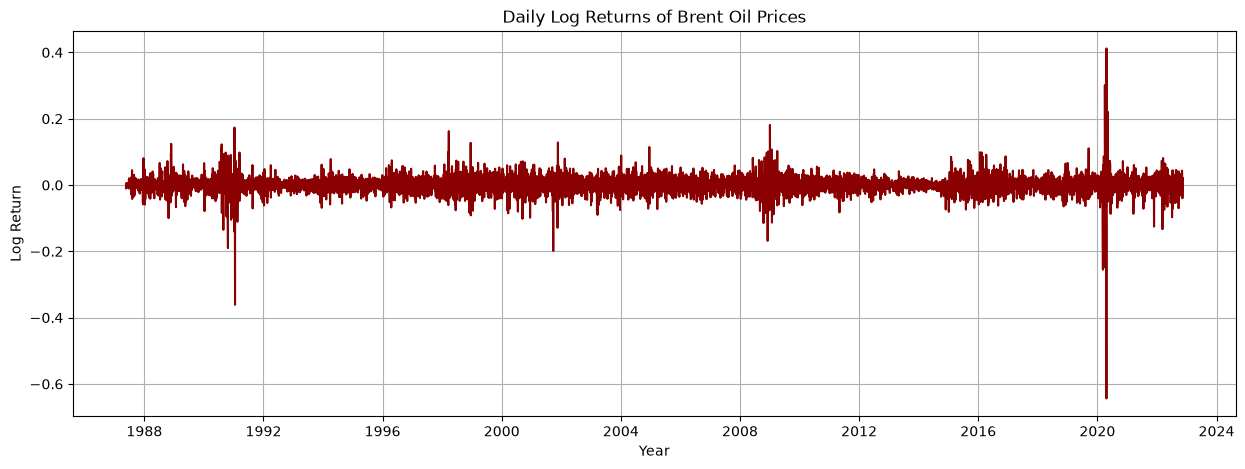

In [18]:
plt.figure(figsize=(15,5))

plt.plot(df.index, df["Log_Return"], color="darkred")

plt.title("Daily Log Returns of Brent Oil Prices")
plt.xlabel("Year")
plt.ylabel("Log Return")

plt.grid(True)

plt.show()

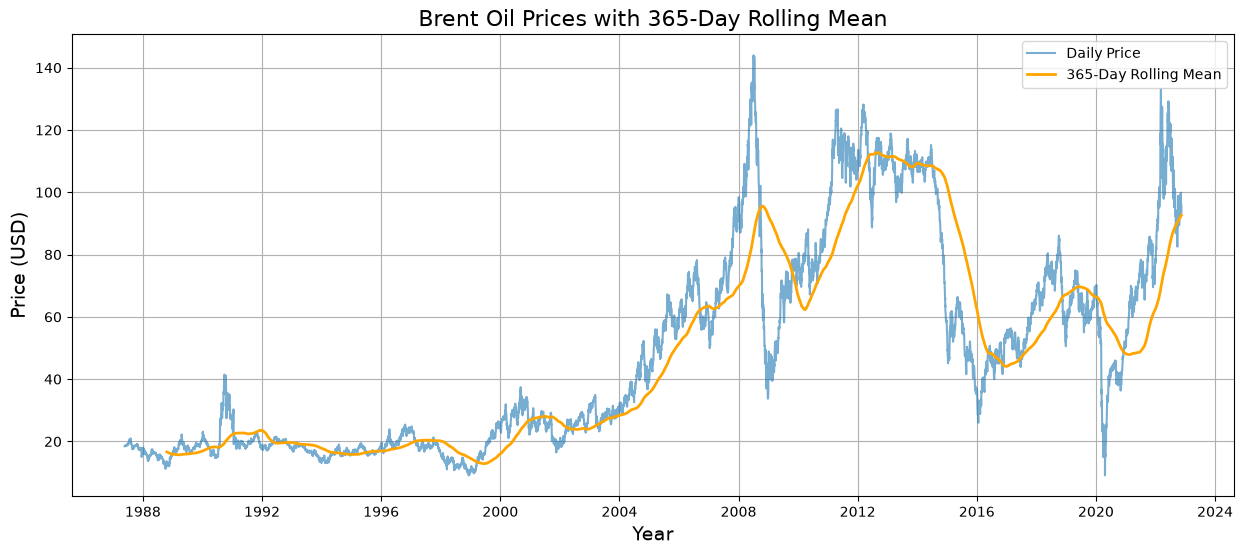

In [19]:
plt.figure(figsize= (15,6))

plt.plot(df.index, df["Price"], label= "Daily Price", alpha=0.6)

rolling_mean = df["Price"].rolling(window=365).mean()

plt.plot(df.index, rolling_mean, color="orange", linewidth=2, label="365-Day Rolling Mean")

plt.title("Brent Oil Prices with 365-Day Rolling Mean", fontsize=16)

plt.xlabel("Year", fontsize=14)

plt.ylabel("Price (USD)", fontsize=14)

plt.legend()

plt.grid(True)

plt.show()

### Trend Analysis

The 365-day rolling mean smooths short-term fluctuations and highlights the long-term trend in Brent oil prices. The series does not fluctuate around a constant average, indicating that the mean changes over time. This suggests that the raw price series is non-stationary and contains structural changes.

In [20]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["Price"])

print("ADF Statistic: %f" % result[0])

print("ADF Statistic", result[0])

print("p-value:", result[1])


ADF Statistic: -1.991854
ADF Statistic -1.9918544071295254
p-value: 0.2901560392642215


we fail to reject Ho, this series is non-stationary

In [21]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["Log_Return"])

print("ADF Statistic: %f" % result[0])

print("ADF Statistic", result[0])

print("p-value:", result[1])

ADF Statistic: -16.427113
ADF Statistic -16.427113494485894
p-value: 2.4985801611428892e-29


Since the p-value is significantly smaller than the 0.05 significance level, the null hypothesis of non-stationarity is rejected.

This indicates that the daily log return series is stationary. Unlike the raw price series, the log returns fluctuate around a relatively constant mean, making them more suitable for statistical analysis and many time series models.

volatility over 30 days 

In [22]:
rolling_vol = df["Log_Return"].rolling(window=30).std()

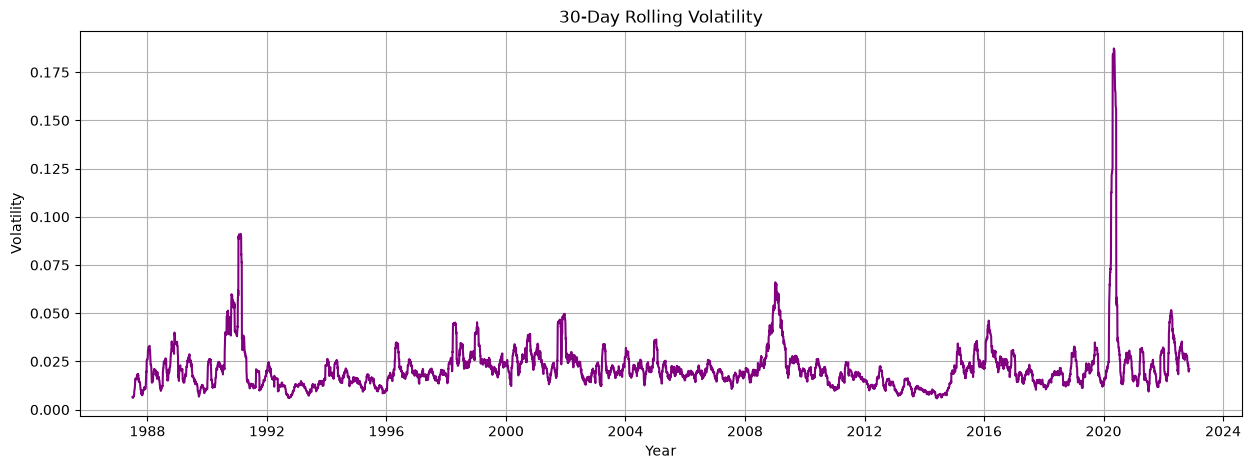

In [23]:
plt.figure(figsize=(15,5))

plt.plot(df.index,
         rolling_vol,
         color="purple")

plt.title("30-Day Rolling Volatility")

plt.xlabel("Year")

plt.ylabel("Volatility")

plt.grid(True)

plt.show()

In [24]:
import pymc as pm
import arviz as az
import scipy
 


g++ not available, if using conda: `conda install gxx`


In [25]:
prices = df["Price"].values

In [26]:
len(prices)

9010

In [27]:
n = len(prices)

time_index = np.arange(n)

In [31]:
with pm.Model() as model:
    tau = pm.DiscreteUniform(
        "tau",
        lower=0,
        upper=n-1
    )

    mu_1 = pm.Normal(
        "mu_1",
        mu=np.mean(prices),
        sigma=np.std(prices)
    )

    mu_2 = pm.Normal(
        
        "mu_2",
        mu=np.mean(prices),
        sigma=np.std(prices)
    )

    sigma= pm.HalfNormal(
        "sigma",      
        sigma=np.std(prices)
    )
    mean = pm.math.switch(
        tau > time_index,
        mu_1,
        mu_2)
    obs = pm.Normal(
        "obs",
        mu=mean,
        sigma=sigma,
        observed=prices
    )

In [32]:
with model:
    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        cores=1,
        random_seed=42
    )

Sequential sampling (2 chains in 1 job)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu_1, mu_2, sigma]


c:\Users\mijuu\Documents\mijuuhailu\change-point-analysis\venv\Lib\site-packages\rich\live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 8 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


"The simple single change-point model may not fully capture multiple structural breaks in a long historical series."

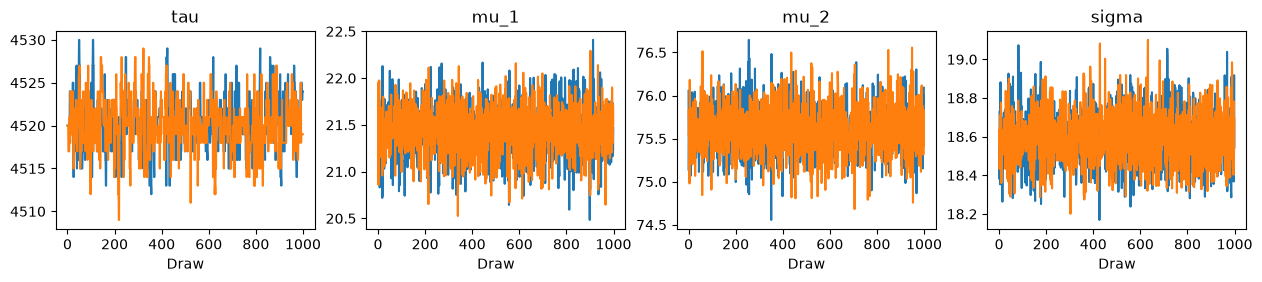

In [33]:
az.plot_trace(
    trace,
    var_names=["tau", "mu_1", "mu_2", "sigma"]
)

plt.show()

In [37]:
tau_samples = trace.posterior["tau"].values.flatten()

estimated_tau = int(np.median(tau_samples))

print("Estimated Tau:", estimated_tau)

print("Estimated Date:", df.index[estimated_tau])

Estimated Tau: 4520
Estimated Date: 2005-02-24 00:00:00


In [35]:
prices = df["Price"].values

In [36]:
change_date = df.index[estimated_tau]

print(change_date)

2005-02-24 00:00:00


In [38]:
az.summary(
    trace,
    var_names=["tau", "mu_1", "mu_2", "sigma"]
)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
tau,4520.1,3.2,4500,4500,527,542,1.01,0.14,0.1
mu_1,21.42,0.272,21,22,2685,1382,1.00,0.0053,0.0037
mu_2,75.608,0.28,75,76,3434,1686,1.00,0.0048,0.0035
sigma,18.598,0.136,18,19,2933,1407,1.00,0.0025,0.0018


In [40]:
increase = ((75.608 - 21.42) / 21.42) * 100
print(f"{increase:.2f}%")

252.98%


The Bayesian change point model identified 24 February 2005 as the most probable structural break in the Brent oil price series. The estimated average price shifted from approximately $21.42 per barrel before the change to $75.61 afterward, representing an increase of approximately 253%. This transition coincides with a period of rapidly increasing global demand and geopolitical instability, suggesting the beginning of a sustained high-price regime.

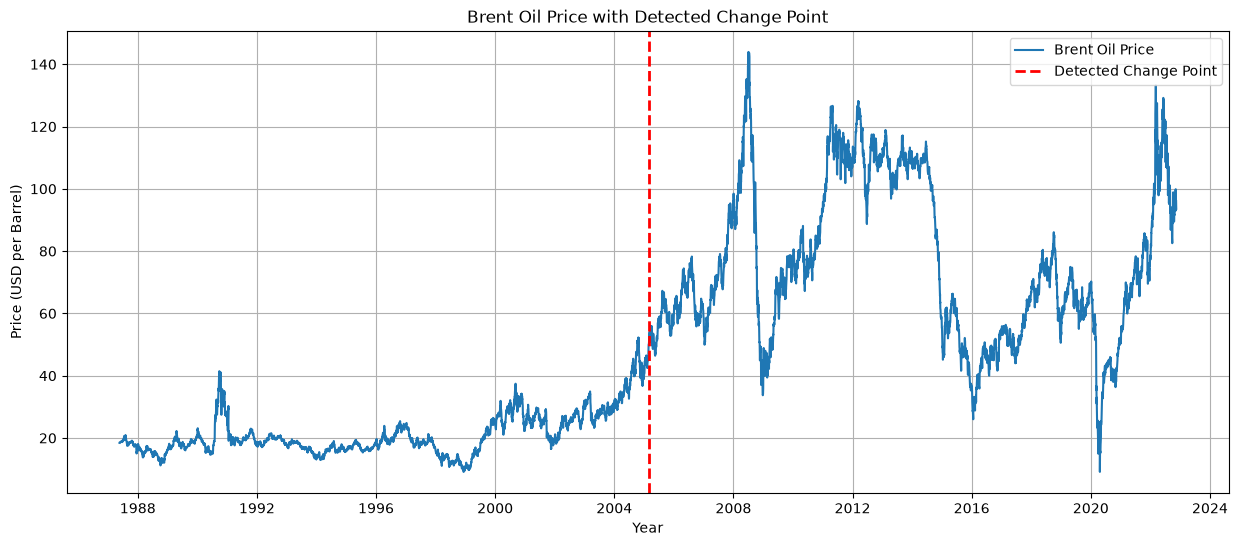

In [39]:
plt.figure(figsize=(15,6))

plt.plot(df.index, df["Price"], label="Brent Oil Price")

plt.axvline(
    df.index[estimated_tau],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Detected Change Point"
)

plt.title("Brent Oil Price with Detected Change Point")
plt.xlabel("Year")
plt.ylabel("Price (USD per Barrel)")
plt.legend()
plt.grid(True)

plt.show()